# Portfolio Metrics

*Note:* The `massive` library was installed with the Python 3.13.3 kernel, so use that one.

In [1]:
import pandas as pd
import numpy as np
from massive import RESTClient

In [2]:
import matplotlib.pyplot as plt

In [3]:
import time
from datetime import date, timedelta

In [4]:
client = RESTClient(api_key="VCxJoIX_gwKwnjixMrg9EdGd6ozcv7Fa")

*Note:* The `Massive` (FKA `Polygon`) API does **not** support Canadian exchanes like the TSX.

In [81]:
tickers = ["SPY", "QQQ", "DFAI", "TLT", "SCHQ", "META", "JPM", "MSFT", 
           "NVDA", "PLTR", "TSLA", "AMZN", "NFLX", "GOOG", "ORACL", 
           "GLD", "COST", "VDC", "VGLT", "IEI", "VCLT"]
years = 5

*Note:* The `Massive` API maxes out at 500 days of historical data, so some other choices (which should give 5+ years for free) are:
- Alpha Vantage
- Tiingo

In [83]:
print(f'Est. Runtime for Data Retrieval: {(1/5)*len(tickers):.1f} min')

Est. Runtime for Data Retrieval: 4.2 min


In [85]:
def get_daily_bars(symbol, start_date, end_date): 
    """Return a DataFrame of daily bars for one symbol."""
    aggs = client.get_aggs(
        ticker=symbol,
        multiplier=1,
        timespan="day",
        from_=start_date.isoformat(),
        to=end_date.isoformat(),
    ) 

    rows = [] 
    for bar in aggs:
        # optionally skip bars with no prices
        if bar.open is None or bar.close is None:
            continue

        rows.append({
            "symbol": symbol,
            "timestamp": pd.to_datetime(bar.timestamp, unit="ms"),
            "open": bar.open,
            "high": bar.high,
            "low": bar.low,
            "close": bar.close,
            "volume": bar.volume,
            "vwap": bar.vwap,
        })

    if not rows:
        # no data for this symbol in this date range
        return pd.DataFrame()   # empty frame is fine, no index set

    df = pd.DataFrame(rows).set_index("timestamp").sort_index() 
    return df



end_date = date.today()
start_date = end_date - timedelta(days=years*365)

all_dfs = []
for t in tickers:
    df_t = get_daily_bars(t, start_date, end_date)
    all_dfs.append(df_t)
    time.sleep(12) # ensure we don't exceed API call limit of 5 calls/minute = (1 call per 12 sec)

# Combine all into a single DataFrame with (date, symbol) index
data = pd.concat(all_dfs)

In [88]:
close_prices = data.pivot_table(values="close", index=data.index, columns="symbol")
print(close_prices.tail())

symbol                 AMZN    COST   DFAI     GLD    GOOG     IEI     JPM  \
timestamp                                                                    
2025-11-14 05:00:00  234.69  922.98  37.09  375.96  276.98  119.42  303.61   
2025-11-17 05:00:00  232.87  912.59  36.64  371.65  285.60  119.47  300.37   
2025-11-18 05:00:00  222.55  895.08  36.26  374.35  284.96  119.65  299.41   
2025-11-19 05:00:00  222.69  890.60  36.15  374.96  292.99  119.62  303.27   
2025-11-20 05:00:00  217.14  893.29  35.69  374.85  289.98  119.82  298.38   

symbol                 META    MSFT     NFLX    NVDA     PLTR     QQQ   SCHQ  \
timestamp                                                                      
2025-11-14 05:00:00  609.46  510.18  111.217  190.17  174.010  608.86  32.16   
2025-11-17 05:00:00  602.01  507.49  110.290  186.60  171.250  603.66  32.23   
2025-11-18 05:00:00  597.69  493.79  114.090  181.36  167.330  596.31  32.20   
2025-11-19 05:00:00  590.32  487.12  110.000  186.52 

In [89]:
close_prices.head()

symbol,AMZN,COST,DFAI,GLD,GOOG,IEI,JPM,META,MSFT,NFLX,NVDA,PLTR,QQQ,SCHQ,SPY,TLT,TSLA,VCLT,VDC,VGLT
timestamp,,,,,,,,,,,,,,,,,,,,
2023-11-22 05:00:00,146.71,589.08,27.13,184.56,140.02,114.26,153.33,341.49,377.85,47.800,48.716,19.69,390.06,32.39,455.02,90.87,234.21,74.46,185.56,56.76
2023-11-24 05:00:00,146.74,591.36,27.32,185.52,138.22,113.98,153.54,338.23,377.43,47.956,47.776,19.20,389.51,32.04,455.30,89.80,235.45,73.88,186.08,56.15
2023-11-27 05:00:00,147.73,594.90,27.25,186.77,138.05,114.44,153.19,334.70,378.61,47.917,48.242,19.08,389.17,32.50,454.48,91.30,236.08,74.78,185.73,56.99
2023-11-28 05:00:00,147.03,594.00,27.29,189.26,138.62,114.90,153.54,338.99,382.70,47.900,47.821,19.71,390.19,32.57,454.93,91.48,246.72,75.09,186.22,57.12
2023-11-29 05:00:00,146.32,587.86,27.35,189.54,136.40,115.28,154.32,332.20,378.85,47.719,48.140,19.84,389.81,32.96,454.61,92.63,244.14,76.01,184.83,57.80


In [90]:
(1+close_prices.pct_change().mean())**252 - 1

symbol
AMZN    0.279580
COST    0.259962
DFAI    0.159746
GLD     0.451080
GOOG    0.507680
IEI     0.025094
JPM     0.438608
META    0.408654
MSFT    0.153866
NFLX    0.567496
NVDA    1.203273
PLTR    2.496020
QQQ     0.254059
SCHQ    0.006039
SPY     0.215265
TLT     0.000153
TSLA    0.585339
VCLT    0.019139
VDC     0.072249
VGLT    0.008568
dtype: float64

In [91]:
close_prices.pct_change().mean() * 252

symbol
AMZN    0.246652
COST    0.231187
DFAI    0.148244
GLD     0.372583
GOOG    0.410906
IEI     0.024785
JPM     0.363938
META    0.342868
MSFT    0.143159
NFLX    0.449880
NVDA    0.791183
PLTR    1.254739
QQQ     0.226487
SCHQ    0.006021
SPY     0.195037
TLT     0.000153
TSLA    0.461220
VCLT    0.018958
VDC     0.069768
VGLT    0.008531
dtype: float64

In [92]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = prices / roll_max - 1
    return drawdown.min()

In [126]:
class Portfolio:
    '''
    Requires:
        - numpy as np
        - pandas as pd
    '''

    def __init__(self, tickers, df, quantities={}, weights={}):
        '''
        tickers: list of tickers
        quantities: dictionary mapping entries of tickers to quantities (int or float)
        df: dataframe of data from massive API as in the format above
        '''
        self.tickers = tickers
        self.quantities = quantities
        self.data = df


    def holding_data(self, holding):
        df = self.data
        if holding != 'all':
            df = df[holding]
        return df


    def returns(self, holding='all', log=False):
        '''
        The log returns (i.e. log(P[t]/P[t-1]) = log(P[t]) - log(P[t-1]) )
        or the ordinary returns if log=False.
        '''
        df = self.holding_data(holding)
        if log:
            return np.log(df).diff().dropna()
        else:
            return df.pct_change().dropna()
        

    def uni_summary(self, holding='all', log=False, tail=0.05, k=4):
        '''
        Returns a univariate summary of the returns of each security (individually), including:
            - the first k (sample) moments of the holdiing returns, 
            - some risk metrics (ES/CVaR, VaR, volatlity, Max DrawDown (MaxDD), Avg DrawDown (AvgDD))
        Note: 
        - The first moment is annualized (geometrically). 
        - The standard deviation is also annualized (by using the airthmetic sum approximation to the geometric annualization). 
            - If log=True, this approximation is exact.
        - We assume 252 trading days in a year.
        - The 2nd, 3rd, 4th moments (and higher) are all standardized.
        - The 4th moment is reported as excess kurtosis (we subtract 3).
        '''
        df = self.returns(holding=holding, log=log)
        means = df.mean()

        d = {}
        if log:
            d['Mean (CAGR)'] = means * 252
        else: 
            d['Mean (CAGR)'] = (1 + means)**252 - 1 
            # Note: this is equivalent to the expression in the log=True case
            #       although we break up the cases to take advantage of the
            #       simplified formula for log=True.
        d['Volatility'] = df.std() * np.sqrt(252)
        d['Skew'] = df.skew()
        d['Kurtosis'] = df.kurtosis()
        for r in range(5, k+1):
            val = ((df - means)**r).mean() / (d['Volatility'] ** r)
            d[f'{r}-th Std. Moment'] = val

        d[f'VaR({tail*100:.2f}%)'] = df.quantile(tail) 
        d[f'ES({tail*100:.2f}%)'] = df.apply(lambda col: col[col <= col.quantile(tail)].mean())
        d[f'MaxDD'] = max_drawdown( (1+df).cumprod() )

        return pd.DataFrame(d).T
    

    def dependence(self, type='corr', holding='all'):
        df = self.holding_data(holding)
        if type=='corr':
            return df.corr()
        elif type=='cov':
            return df.cov()
        elif type=='coskew':
            ...
        elif type=='cokurt':
            ...


        



Let $R=(R_i)_{i=1}^n$ be a random vector (i.e. returns of various securities), and let $X_i=R_i-\mathbb{E}(R_i)$.

The **Co-skewness** tensor of the random vector $X$ is $\text{Coskew}(X)=[S_{ijk}]_{i,j,k=1}^{n,n,n}\in\mathbb{R}^{n^3}$ given by:
$$
S_{ijk} = \mathbb{E}[ X_i X_j X_k ]
$$

The **Co-kurtosis** tensor of the random vector $X$ is $\text{Cokurt}(X)=[K_{ijkl}]_{i,j,k,l=1}^{n,n,n,n}\in\mathbb{R}^{n^4}$ given by:
$$
K_{ijkl} = \mathbb{E}[ X_i X_j X_k X_l ]
$$

## Testing out the `Portfolio` class

In [127]:
# create instance of Portfolio class
p = Portfolio(tickers=tickers, quantities=qty, df=close_prices)

In [128]:
summary = p.uni_summary()
summary

symbol,AMZN,COST,DFAI,GLD,GOOG,IEI,JPM,META,MSFT,NFLX,NVDA,PLTR,QQQ,SCHQ,SPY,TLT,TSLA,VCLT,VDC,VGLT
Mean (CAGR),0.279580,0.259962,0.159746,0.451080,0.507680,0.025094,0.438608,0.408654,0.153866,0.567496,1.203273,2.496020,0.254059,0.006039,0.215265,0.000153,0.585339,0.019139,0.072249,0.008568
Volatility,0.313796,0.205919,0.141538,0.174448,0.296556,0.040952,0.237675,0.372222,0.220654,0.316145,0.510900,0.660816,0.208494,0.124467,0.163680,0.136688,0.633357,0.107714,0.120419,0.124441
Skew,0.311293,-0.587611,0.039776,-0.471907,0.281614,-0.131131,0.092842,1.403201,0.559190,0.203164,0.181879,1.439648,0.805124,-0.108654,1.139380,-0.140352,0.658723,-0.280795,0.072147,-0.120170
Kurtosis,5.843668,4.939539,12.727066,2.857677,4.714925,1.716205,11.446773,16.240885,8.173988,6.912616,5.008230,10.142011,14.888887,0.614231,24.150290,0.575852,4.642187,2.039101,3.781655,0.623407
VaR(5.00%),-0.028284,-0.017700,-0.012194,-0.017286,-0.027147,-0.004334,-0.019161,-0.029563,-0.021921,-0.026514,-0.046877,-0.051395,-0.020692,-0.013125,-0.015287,-0.014369,-0.055516,-0.010142,-0.011534,-0.012921
ES(5.00%),-0.043138,-0.030575,-0.019271,-0.024093,-0.041531,-0.006016,-0.036713,-0.049315,-0.031414,-0.043478,-0.070718,-0.083318,-0.030832,-0.017508,-0.023788,-0.019288,-0.080814,-0.015900,-0.015747,-0.017568
MaxDD,-0.308766,-0.172966,-0.135185,-0.101277,-0.294305,-0.047076,-0.248866,-0.342093,-0.241680,-0.210906,-0.368868,-0.406115,-0.228833,-0.153419,-0.189989,-0.171321,-0.537657,-0.125791,-0.094048,-0.153250


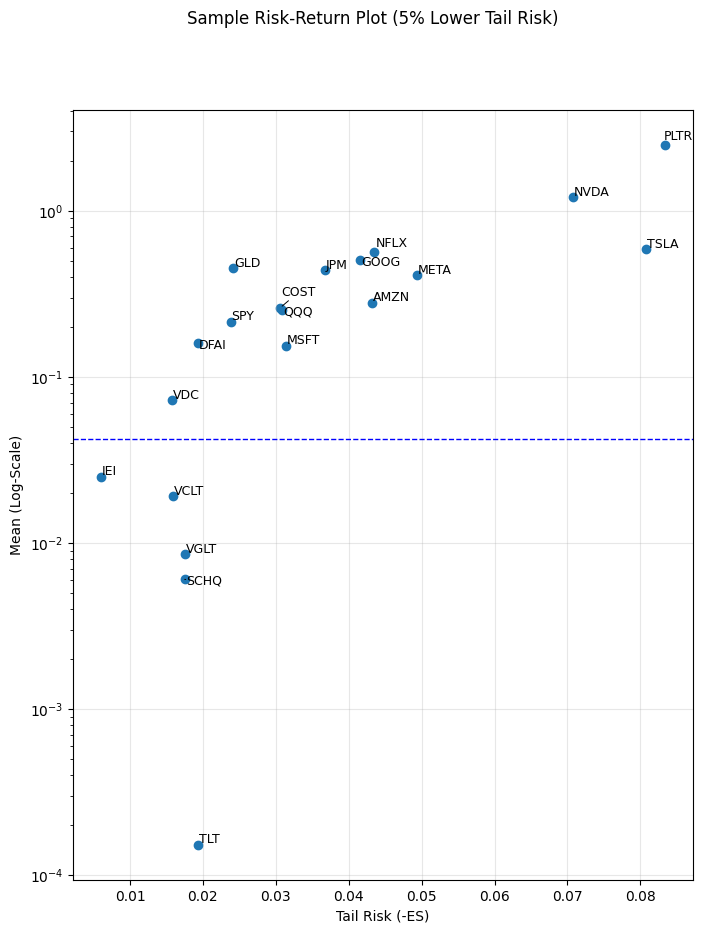

In [ ]:
from adjustText import adjust_text

summary = p.uni_summary()

fig, ax = plt.subplots(figsize=(8, 10))
x = -summary.loc['ES(5.00%)'] ; y = summary.loc['Mean (CAGR)']
ax.scatter(x=x, y=y)
texts = []
for t in summary.columns:
    texts.append(ax.text(x[t], y[t], t, fontsize=9))

ax.set_yscale("log")

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', lw=0.7))

ax.set_xlabel('Tail Risk (-ES)') ; ax.set_ylabel('Mean (Log-Scale)')
fig.suptitle(f'Sample Risk-Return Plot (5% Lower Tail Risk)')

ax.grid(True, alpha=0.3)

rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)

plt.show()


For this particular collection of securities, the classic risk-return plot using volatility actually turns out to look pretty much identical, although ES (a.k.a. CVaR) has the benefit of being a coherent risk measure, as well as arguably being a more intuitive risk measure (the 5% ES is the expected return amongst the bottom 5% worst cases).

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

In [131]:
# quantities of each holding
qty = {
    "DFAI":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SCHQ":45
}

# tickers
my_pft = qty.keys()

# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=close_prices, quantities=qty)

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

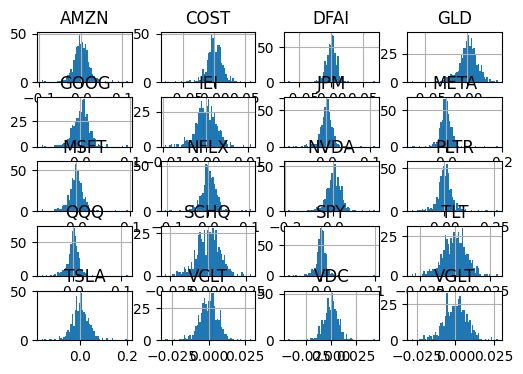

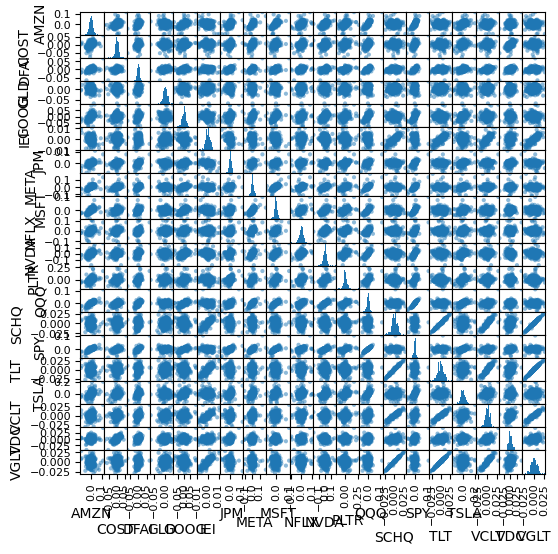

In [113]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()